# Lineare Kongruenzgeneratoren und MCMC

Dieses Notebook zeigt zwei zentrale Ideen aus der Simulation:

1. Wie man mit einem linearen Kongruenzgenerator Pseudozufallszahlen erzeugt.
2. Wie man mit Markov Chain Monte Carlo (hier: Metropolis) aus einer Zielverteilung sampelt und Integrale approximiert.

Die Beispiele sind bewusst kompakt gehalten, damit man die Methoden leicht verändern und selbst ausprobieren kann.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
np.set_printoptions(precision=4, suppress=True)

SEED = 20260525
rng = np.random.default_rng(SEED)

## 1. Linearer Kongruenzgenerator

Ein linearer Kongruenzgenerator (LCG) erzeugt rekursiv ganze Zahlen

$$x_{n+1} = (a x_n + c) mod m.$$

Die normierten Werte $u_n = x_n / m$ liegen dann in $[0,1)$ und dienen als Pseudozufallszahlen.

Wichtig: Ein LCG ist deterministisch. Er ist also kein echter Zufall, sondern nur eine reproduzierbare Folge, die zufällig aussehen soll.

In [4]:
def lcg(n, seed=1, a=1664525, c=1013904223, m=2**32):
    """Erzeugt n Werte eines linearen Kongruenzgenerators."""
    values = np.empty(n, dtype=np.uint64)
    x = np.uint64(seed)
    for i in range(n):
        x = (np.uint64(a) * x + np.uint64(c)) % np.uint64(m)
        values[i] = x
    return values, values / float(m)

def summarize_uniform_sample(sample):
    return {
        'Mittelwert': float(np.mean(sample)),
        'Varianz': float(np.var(sample)),
        'Minimum': float(np.min(sample)),
        'Maximum': float(np.max(sample)),
    }

raw_lcg, u_lcg = lcg(10_000, seed=123456789)
summary = summarize_uniform_sample(u_lcg)
summary

{'Mittelwert': 0.49381329340357333,
 'Varianz': 0.08386810657690953,
 'Minimum': 5.5162934586405754e-05,
 'Maximum': 0.999944209586829}

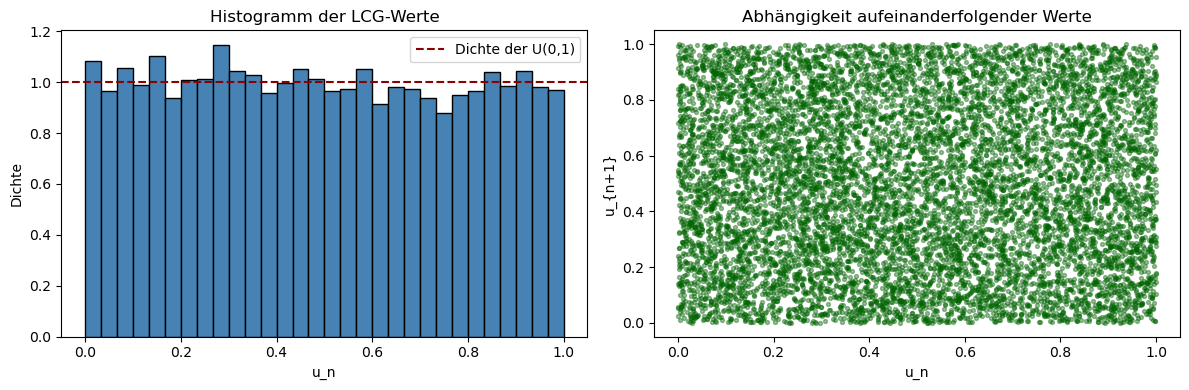

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(u_lcg, bins=30, density=True, color='steelblue', edgecolor='black')
axes[0].axhline(1.0, color='darkred', linestyle='--', label='Dichte der U(0,1)')
axes[0].set_title('Histogramm der LCG-Werte')
axes[0].set_xlabel('u_n')
axes[0].set_ylabel('Dichte')
axes[0].legend()

axes[1].scatter(u_lcg[:-1], u_lcg[1:], s=8, alpha=0.4, color='darkgreen')
axes[1].set_title('Abhängigkeit aufeinanderfolgender Werte')
axes[1].set_xlabel('u_n')
axes[1].set_ylabel('u_{n+1}')

plt.tight_layout()
plt.show()

### Interpretation

- Das Histogramm sollte ungefähr flach sein, wenn die Zahlen grob gleichverteilt wirken.
- Der Scatterplot $(u_n, u_{n+1})$ hilft, versteckte Struktur sichtbar zu machen.
- Auch wenn ein LCG oft gut genug für einfache Aufgaben ist, hat er systematische Schwächen. Für moderne Anwendungen nutzt man meist bessere Generatoren.

## 2. MCMC mit dem Metropolis-Algorithmus

Jetzt wollen wir nicht einfach aus der Gleichverteilung sampeln, sondern aus einer komplizierteren Zielverteilung.

Wir nehmen als Ziel die Standardnormalverteilung mit Dichte

$$i(x) = rac{1}{qrt{2i}} e^{-x^2/2}. $$

Beim Metropolis-Algorithmus schlagen wir ausgehend vom aktuellen Zustand $x$ einen neuen Zustand $y$ vor und akzeptieren ihn mit einer passenden Wahrscheinlichkeit.

In [9]:
def normal_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)

def metropolis(target_pdf, n_steps, x0=0.0, proposal_sigma=1.0, seed=1234):
    rng_local = np.random.default_rng(seed)
    chain = np.empty(n_steps)
    chain[0] = x0
    accepts = 0

    for n in range(1, n_steps):
        x = chain[n - 1]
        y = x + rng_local.normal(0.0, proposal_sigma)

        alpha = min(1.0, target_pdf(y) / target_pdf(x))
        if rng_local.uniform() < alpha:
            chain[n] = y
            accepts += 1
        else:
            chain[n] = x

    acceptance_rate = accepts / (n_steps - 1)
    return chain, acceptance_rate

chain, acceptance_rate = metropolis(normal_pdf, n_steps=25_000, x0=8.0, proposal_sigma=1.2, seed=SEED)
acceptance_rate

0.655946237849514

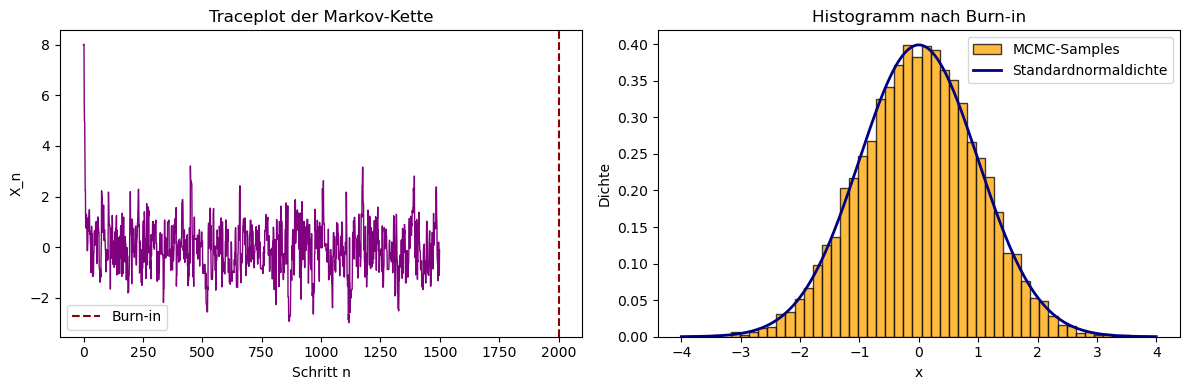

In [10]:
burn_in = 2_000
samples = chain[burn_in:]
x_grid = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(chain[:1500], color='purple', linewidth=1)
axes[0].axvline(burn_in, color='darkred', linestyle='--', label='Burn-in')
axes[0].set_title('Traceplot der Markov-Kette')
axes[0].set_xlabel('Schritt n')
axes[0].set_ylabel('X_n')
axes[0].legend()

axes[1].hist(samples, bins=50, density=True, alpha=0.75, color='orange', edgecolor='black', label='MCMC-Samples')
axes[1].plot(x_grid, normal_pdf(x_grid), color='navy', linewidth=2, label='Standardnormaldichte')
axes[1].set_title('Histogramm nach Burn-in')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Dichte')
axes[1].legend()

plt.tight_layout()
plt.show()

### Was sieht man?

- Der Traceplot zeigt, wie die Kette vom Startwert aus die Zielverteilung erkundet.
- Nach dem Burn-in sehen die besuchten Zustände wie ein Sample aus der Standardnormalverteilung aus.
- Die Akzeptanzrate sollte weder extrem klein noch extrem groß sein. Mit der Schrittweite `proposal_sigma` kann man das Verhalten steuern.

## 3. MCMC-Integration

Es gibt zwei wichtige Fälle:

1. **Erwartungswert unter einer Zielverteilung**
   $$athbb E_i[g] pprox rac{1}{N-B} um_{n=B+1}^N g(X_n).$$
2. **Allgemeines Integral durch künstliches Einführen einer Verteilung**
   $$nt h(x)dx = nt rac{h(x)}{i(x)}i(x)dx = athbb E_ieft[rac{h(X)}{i(X)}
ight].$$

Damit kann man auch Integrale approximieren, wenn man die Verteilung $i$ nicht ursprünglich gegeben hatte, sondern nur als Hilfsmittel einführt.

In [11]:
# Beispiel 1: Erwartungswert E_pi[X^2] unter der Standardnormalverteilung
estimate_second_moment = np.mean(samples**2)

# Beispiel 2: Allgemeines Integral
# Wir wollen I = ∫ x^2 * exp(-x^2 / 2) dx über R berechnen.
# Mit pi = N(0,1) gilt h(x)/pi(x) = sqrt(2*pi) * x^2.
integral_estimate = np.mean(np.sqrt(2.0 * np.pi) * samples**2)
exact_integral = np.sqrt(2.0 * np.pi)

print('Akzeptanzrate           :', round(acceptance_rate, 4))
print('E_pi[X^2] (MCMC)        :', round(float(estimate_second_moment), 4))
print('E_pi[X^2] (exakt)       :', 1.0)
print()
print('Integral ∫ x^2 exp(-x^2/2) dx (MCMC):', round(float(integral_estimate), 4))
print('Integral ∫ x^2 exp(-x^2/2) dx (exakt):', round(float(exact_integral), 4))

Akzeptanzrate           : 0.6559
E_pi[X^2] (MCMC)        : 0.9825
E_pi[X^2] (exakt)       : 1.0

Integral ∫ x^2 exp(-x^2/2) dx (MCMC): 2.4627
Integral ∫ x^2 exp(-x^2/2) dx (exakt): 2.5066


## 4. Fazit

- Ein LCG erzeugt deterministische, aber oft brauchbare Pseudozufallszahlen.
- MCMC konstruiert eine Markov-Kette, deren stationäre Verteilung die gewünschte Zielverteilung ist.
- Mit diesen Samples kann man nicht nur Verteilungen simulieren, sondern auch Erwartungswerte und allgemeine Integrale numerisch approximieren.

Probier als Nächstes ruhig aus:
- andere Parameter beim LCG,
- andere Schrittweiten im Metropolis-Verfahren,
- andere Funktionen $g$ oder $h$ in der Integrationszelle.